# Optimization in Deep Learning

## Optimization in Deep Learning: The Engine Room

### The Story So Far

We have consistently used optimization algorithms to train our deep learning models. They are the tools that:

- Update model parameters iteratively.
- Aim to minimize the value of a loss function using a training dataset.

### Is a "Black Box" understanding enough?

Anyone can use optimizers like "SGD" or "Adam" to minimize an objective function. However, to achieve high performance and efficiency, a deeper knowledge is required.

## Why Deeper Knowledge is Crucial

### 1. Training Efficiency

- Training a complex model can take hours, days, or even weeks.
- The performance of the optimization algorithm **directly affects** the model’s training time.
- A better algorithm or better tuning can save significant time and computational resources.

### 2. Model Performance

- Understanding the principles of different optimizers helps in hyperparameter tuning.
- This allows us to tune hyperparameters in a **targeted manner**, not just by random guessing.
- The result is often a model with better accuracy and generalization

## The Two Goals

Although we use optimization to perform deep learning, their fundamental goals are different.

![image.png](attachments/opt_image.png)

### Primary Goal

Reducing the training error **is a means to an end, not the end itself.** The ultimate goal is to **reduce generalization error.**

## Illustration: True Risk vs. Empirical Risk

- **True Risk:** The expected loss on the entire population of data. This is smooth. We want to find its true minimum.
- **Empirical Risk:** The average loss on our finite training dataset. It is often noisy and less smooth. This is what we actually minimize

![image-2.png](attachments/opt_image-2.png)

### Key Observation

The minimum of the empirical risk (training error) may be at a different location than the minimum of the true risk (generalization error).

## The Balancing Act of Deep Learning

So, training a deep learning model involves two key aspects:
1. **Optimization:** The process of reducing the training error with algorithms like SGD, Adam, etc.
2. **Regularization:** A collection of techniques (e.g., weight decay, dropout) used to control model complexity and reduce the gap between training and generalization error (i.e., fight overfitting).

### Focus of This Module

In this module, we will focus specifically on the optimization aspect: the algorithms and challenges involved in minimizing the objective function.

## The Landscape of Deep Learning

### Key Property: Nonconvexity

- Almost all optimization problems in deep learning are nonconvex.
- This means the "loss landscape" can be incredibly complex, like a rugged mountain range rather than a simple bowl.

![image-3.png](attachments/opt_image-3.png)



# Major Optimization Challenges

## Major Optimization Challenges

We will explore three of the most significant challenges in deep learning optimization:

1. **Local Minima:** Getting stuck in a "pretty good" valley instead of the best one.
2. **Saddle Points:** Getting stuck on a flat point that is a minimum in one direction but a maximum in another.
3. **Vanishing Gradients:** Gradients becoming so small that learning effectively stops.

## Challenge 1: Local Minima

### Definition

- **Local Minimum: **A point x where f (x ) is the minimum value over any other points in its immediate vicinity.
- **Global Minimum:** A point x where f (x ) is the minimum value over the entire domain.

![image-4.png](attachments/opt_image-4.png)

### The Problem

An optimization algorithm’s updates are based on local gradient information.It can converge to a local minimum and stop, believing it has found the best solution.

## Challenge 2: Saddle Points

### Definition

A saddle point is a location where all gradients of a function vanish (i.e., $\nabla f(x) = 0$), but which is neither a local minimum nor a local maximum.

### The Problem

Optimization might stall at a saddle point because the gradient is zero, providing no direction for the next step.

### Example 1D: 

$f(x) = x^3$ at x = 0, both $f^\prime(0) = 0$ and $f^{\prime\prime}(0) = 0$ The gradient is zero, but it’s clearly not a minimum.

![image-5.png](attachments/opt_image-5.png)

## Saddle Points in Higher Dimensions

### Saddle Points are More Common than Minima in High Dimensions!

At a zero-gradient point, the type of point depends on the **Hessian matrix** (matrix of second derivatives).

- **Local Minimum:** All eigenvalues of the Hessian are positive.
- **Saddle Point:** Some eigenvalues are positive, and some are negative.

In a high-dimensional space, it’s statistically much more likely to get a mix of positive and negative eigenvalues than for all of them to be positive.

### Example 2D:

$$f(x,y) = x^2-y^2$$

- At (0, 0), the gradient is [0, 0].
- It’s a minimum with respect to x .
- It’s a maximum with respect to y .
- The shape is literally a saddle!

![image-6.png](attachments/opt_image-6.png)

## Challenge 3: Vanishing Gradients

### Definition

The vanishing gradient problem occurs when gradients become infinitesimally small, causing the updates to the model’s parameters to become negligible. Learning effectively stops.

### The Problem

Even if we are not at a minimum or a saddle point, optimization can get stuck for a very long time if the landscape is almost flat.

### Example:

$$f(x) = tanh(x)$$

The Derivative is: $f^\prime(x) = 1- tanh^2(x)$

If we start at x = 4, the gradient is $f^\prime(4) \sim 0.0013$ The parameter updates will be tiny, and progress will be extremely slow.

![image-7.png](attachments/opt_image-7.png)



# A Primer on Convex Optimization

## Why Study Convexity?

### A Paradox

The optimization problems in deep learning are generally nonconvex. So why dedicate a section to convexity?

### The Reasons

- **Analytical Tractability:** Convex problems are much easier to analyze and understand. They provide a theoretical foundation.
- **Algorithm Design & Testing:** If an algorithm performs poorly even in a simple convex setting, it is unlikely to work well on complex nonconvex problems. Convexity provides a crucial sanity check.
- **Local Properties:** Even though the global loss landscape is nonconvex, it often exhibits convex-like properties near a local minimum. This insight can lead to better optimization algorithms.

## Convex Sets: The Foundation

### Definition

A set X in a vector space is convex if for any two points $a,b \in X $, the entire line segment
connecting a and b is also in X .

![image-8.png](attachments/opt_image-8.png)

### Mathematical Formulation

For $\lambda \in [0,1]$, we have: $$\lambda a + (1-\lambda)b \in X \text{   Whenever a,b } \in X$$

### Examples: Convex vs. Nonconvex Sets

![image-9.png](attachments/opt_image-9.png)

## Properties of Convex Sets

### Intersection

The intersection of two (or any number of) convex sets is also convex.

**Proof Sketch:** If points a, b are in the intersection $X \cap Y,$ they are in X and they are in Y. Since both sets are convex, the line segment connecting a, b must be in X and in Y. Therefore, the segment must be in their intersection.

![image-10.png](attachments/opt_image-10.png)

### Union

The union of two convex sets is not necessarily convex.

**Counter example:** Consider two disjoint convex sets X and Y. Pick a point $a \in X$ and $b \in Y$. The line segment between them must contain points that are in neither set.

![image-11.png](attachments/opt_image-11.png)

## Convex Functions

![image-12.png](attachments/opt_image-12.png)

**Visual Intuition**

The line segment connecting any two points on the function’s graph (the chord) lies at or above the graph of the function.

![image-13.png](attachments/opt_image-13.png)

### Examples of Functions

![image-14.png](attachments/opt_image-14.png)

## Key Property 1: Local Minima Are Global Minima

### Theorem

For a convex function f , any local minimum is also a global minimum.

![image-15.png](attachments/opt_image-15.png)

## Key Property 2: Second Derivatives

![image-16.png](attachments/opt_image-16.png)

## Jensen’s Inequality: A Powerful Tool

![image-17.png](attachments/opt_image-17.png)

**Intuition**

The average of the function’s values is greater than or equal to the function evaluated at the average input.

## Handling Constraints

Convex optimization provides powerful tools for handling constraints efficiently.

![image-18.png](attachments/opt_image-18.png)

### How can we solve this?

There are several strategies. We will look at three common ones:

1. The Lagrangian
2. Penalties
3. Projections

## Constraints: The Lagrangian

The Lagrangian method converts a constrained problem into an unconstrained one.

![image-19.png](attachments/opt_image-19.png)

![image-20.png](attachments/opt_image-20.png)

## Constraints: Penalties

![image-21.png](attachments/opt_image-21.png)

## Constraints: Projections

![image-22.png](attachments/opt_image-22.png)

## Put it together

### Local Minima are Global Minima

For a convex function, any local minimum is also a global minimum. This means we cannot "get stuck" in a suboptimal valley.

### Second Derivative Condition

A twice-differentiable function f is convex if and only if its second derivative (Hessian matrix) is positive semidefinite. This condition relates convexity to the function’s curvature.

### Jensen’s Inequality

A cornerstone of convex analysis. For a convex function f and a random variable X : $$ E[f(X)] \geq f(E[X]) $$

The expectation of the function is greater than or equal to the function of the expectation.

# Gradient Descent Algorithms

## Gradient Descent: The Core Idea

### Taylor Expansion

For a small displacement $\epsilon$, we can approximate the function value using a first-order Taylor
expansion: $$f(x + \epsilon) \approx f(x) + \epsilon^T \nabla f(x)$$

### Which direction to move?

- To make $f(x+\epsilon)$ as small as possible, we need to make the term $\epsilon^T \nabla f(x)$ as negative as possible.
- The direction that maximally decreases the value is the direction opposite to the gradient, i.e., $- \nabla f(x)$.
- So, we should choose our displacement $\epsilon$ to be proportional to the negative gradient: $$\epsilon = - \eta \nabla f(x)$$ here, $\eta > 0$ is a small positive scalar called the **learning rate.**

## The Gradient Descent Algorithm

This leads to the fundamental update rule for Gradient Descent (GD).

![image.png](attachments/opt_image.png)

![image-2.png](attachments/opt_image-2.png)

## The Importance of the Learning Rate (η)

The choice of learning rate is critical for gradient descent to succeed.

![image-3.png](attachments/opt_image-3.png)

## Multivariate Gradient Descent

![image-5.png](attachments/opt_image-5.png)

## Adaptive Methods: Newton’s Method

Gradient descent only uses first-order (gradient) information. Can we do better by using second-order (curvature) information?

![image-4.png](attachments/opt_image-4.png)

This gives the update rule for **Newton’s method**. It uses the inverse Hessian to rescale the gradient, effectively creating a specialized learning rate for each direction.

## Newton’s Method: The Good and The Bad

### The Good: Fast Convergence

For "nice" (e.g., strongly convex) functions, Newton’s method can converge extremely quickly, often in a handful of steps. For a quadratic function, it converges in a **single step!**

![image-6.png](attachments/opt_image-6.png)

### The Bad: Non-convexity & Cost

- If the function is not convex, the Hessian **H** can have negative eigenvalues. In this case, Newton’s method can actually move towards a **maximum**, causing divergence.
- **High Cost:** Computing, storing, and inverting the Hessian is computationally prohibitive for deep learning models. If a model has d parameters, the Hessian is d × d, which requires $O(d^2)$ space and $O(d^3)$ for inversion.

![image-7.png](attachments/opt_image-7.png)

## Batch Gradient Descent

![image-8.png](attachments/opt_image-8.png)

### The Computational Bottleneck

- To compute this gradient, we must perform a **full pass** over the entire training dataset.
- The computational cost for a single gradient update is $O(n)$.
- If n is in the millions or billions (common today), this is extremely slow and inefficient.
- Much of the data in a large dataset is redundant; we shouldn’t need to see all of it to make a small step.

## Stochastic Gradient Descent (SGD): The Solution

### The Core Idea

Instead of computing the gradient on the whole dataset, what if we just pick one example at random and compute the gradient on that?

![image-9.png](attachments/opt_image-9.png)

![image-10.png](attachments/opt_image-10.png)

## Visualizing SGD vs. GD

![image-11.png](attachments/opt_image-11.png)

## Finding the Middle Ground

We have seen two extremes:

![](attachments/03_Convex_Optmisation_and_Gradient_Descentti44517tpm44p.png)

### The Solution: Minibatch Stochastic Gradient Descent

Instead of one example or all examples, we use a small batch of examples. This is the de facto standard for training deep neural networks.

##  The Power of Vectorization

The primary motivation for minibatchs is computational efficiency. Modern CPUs and GPUs
are parallel processors designed to perform the same operation parallely.

### Matrix Multiplication Example

Consider computing $A = BC$ where matrices are 256 $\times$ 256.

- **SGD-like (Element by element):** Computing each element $A_{ij}$ via a dot product is extremely slow. It requires many separate, small memory accesses.
- **Minibatch-like (Block by block):** Multiplying blocks of the matrices is much faster as it keeps data in fast cache memory.
- **GD-like (Full matrix):** Performing the entire operation at once is the fastest, as it can be handed off to a highly optimized library (like BLAS) that makes maximal use of vectorization and parallel cores.

The primary motivation for mini-batches is computational efficiency.

![](attachments/03_Convex_Optmisation_and_Gradient_Descentti48528tpm48p.png)

## The Minibatch SGD Algorithm

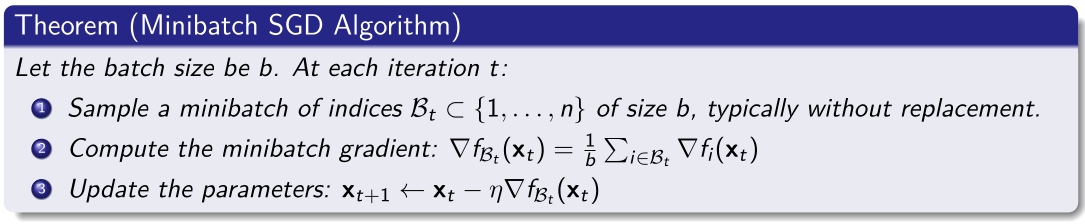

### The Best of Both Worlds

- **Computational Efficiency:** It is significantly faster than one-by-one SGD due to vectorization.
- **Statistical Efficiency:** Averaging gradients over a minibatch reduces $\sqrt{b}$ the variance of the gradient estimate. The standard deviation is reduced by a factor of b compared to SGD. This leads to a more stable convergence path.

## The Final Showdown: Time vs. Loss

### Analysis

- **Batch**: Each step is very slow, but accurate.
- **SGD**: Converges faster than GD in terms of examples processed, but slow in clock time because it’s computationally inefficient.
- **Minibatch**: Offers the best trade-off. It converges quickly and is computationally efficient.

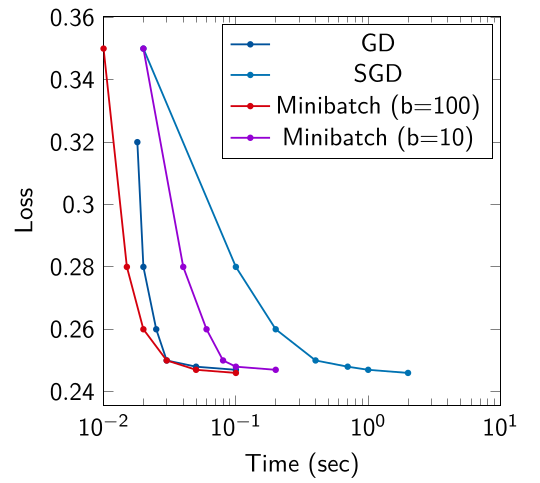

**Minibatch SGD offers the best compromise between statistical and computational efficiency.**

## Summary: Gradient Descent and its Variants

- Batch Gradient Descent uses the full dataset to compute the gradient, resulting in a stable but slow update. The choice of learning rate is critical.
- **Newton’s Method** uses second-order (Hessian) information for faster convergence on convex problems but is computationally infeasible for deep learning and unstable on non-convex problems.
- **Stochastic Gradient Descent (SGD)** uses a single example to compute a cheap but noisy gradient. It requires a decaying learning rate to converge.
- **Minibatch SGD** is the practical standard. It balances the trade-off between the stability of GD and the speed of SGD. Its main advantage comes from leveraging the parallel computing power of modern hardware through **vectorization**.

# Learning Rate Scheduling

## Learning Rate Scheduling

Adjusting the learning rate $\eta$ during training is often as important as the choice of optimizer. This is called **learning rate scheduling**.

### Why Schedule the Learning Rate?

- **Magnitude**: If $\eta$ is too large, the optimizer diverges. If too small, it converges too slowly.
- **Decay**: As we approach a minimum, we need to take smaller steps to avoid overshooting and to settle into the minimum. Therefore, the learning rate should generally decay over time.
- **Warmup**: At the start of training, parameters are random. Large steps might be harmful. A "warmup" period with a small initial learning rate that gradually increases can improve stability.

## Dynamic Learning Rates (Schedules)

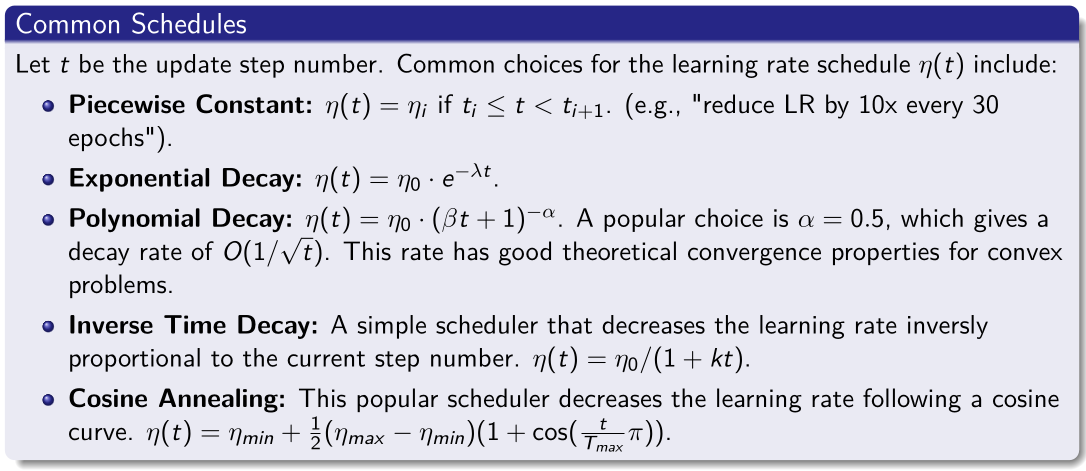

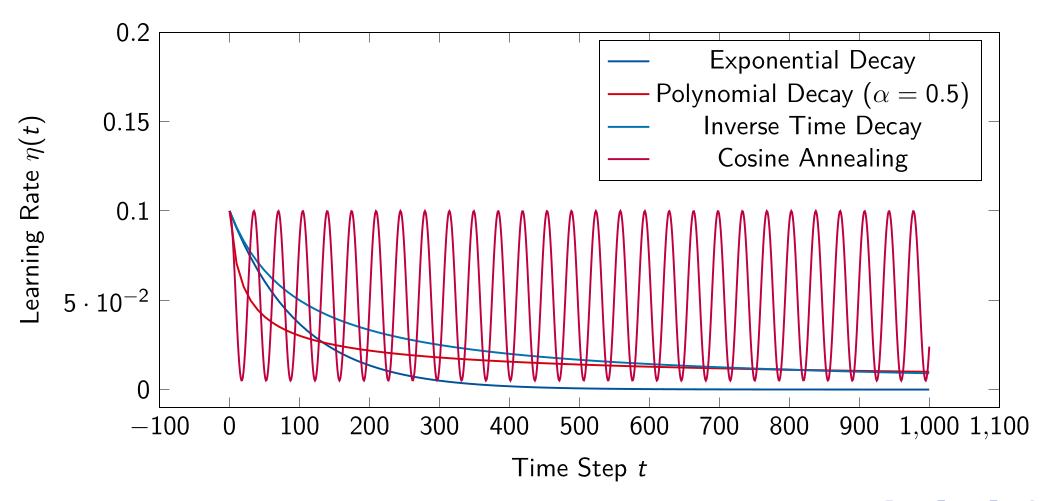

# Accelerated Optimization Methods

## The Problem: Oscillations in GD

Recall our ill-conditioned problem: $f(x_1, x_2) = 0.1x_1^2 + 2x_2^2$

Gradient descent struggles:

- The gradient is much larger in the $x_2$ direction.
- A high learning rate causes divergence in $x_2$.
- A low learning rate causes painfully slow convergence in $x_1$ .
- The optimization path oscillates across the narrow valley instead of moving along it.

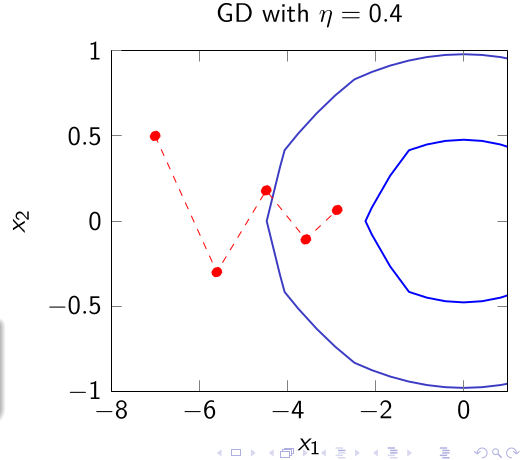

The Question

- Can we "dampen" these oscillations and "accelerate" progress along the flat direction?

# Momentum

## The Momentum Method: A Physical Analogy

### The Core Idea

Imagine a heavy ball rolling down the loss surface.

- The ball accumulates **velocity** (i.e., momentum) as it rolls down.
- In steep directions, its velocity changes often, but the oscillations tend to cancel out.
- In flat directions, it consistently accelerates, building up speed.

We can simulate this by maintaining a "velocity" vector, which is an exponentially weighted moving average of past gradients.

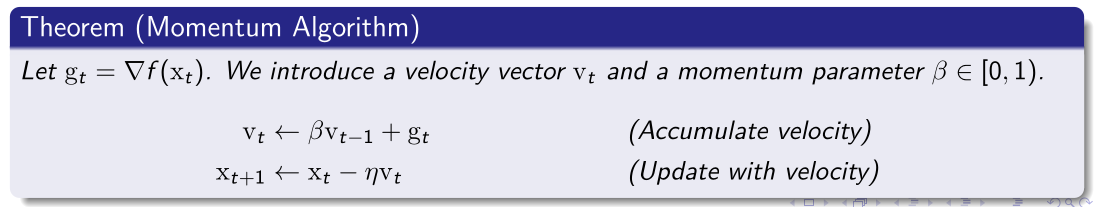

## Understanding Velocity: Leaky Averages

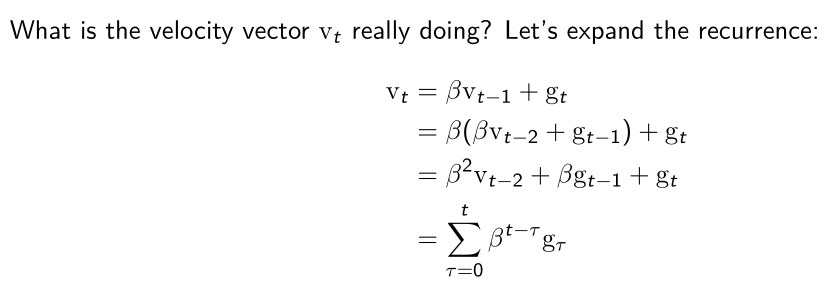

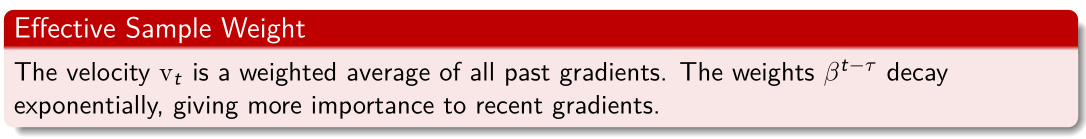

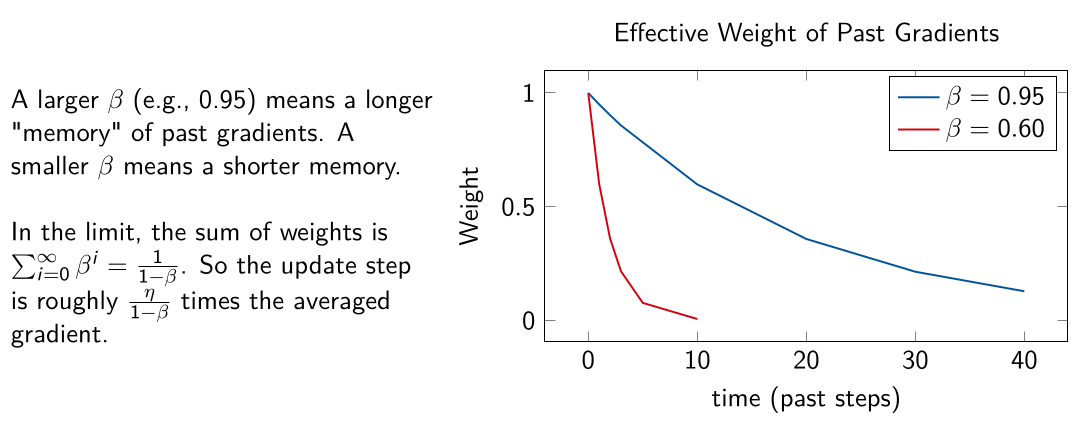

## Momentum in Action

Let’s apply Momentum to the same ill-conditioned problem with a high learning rate $(\eta = 0.6)$ that caused GD to diverge.

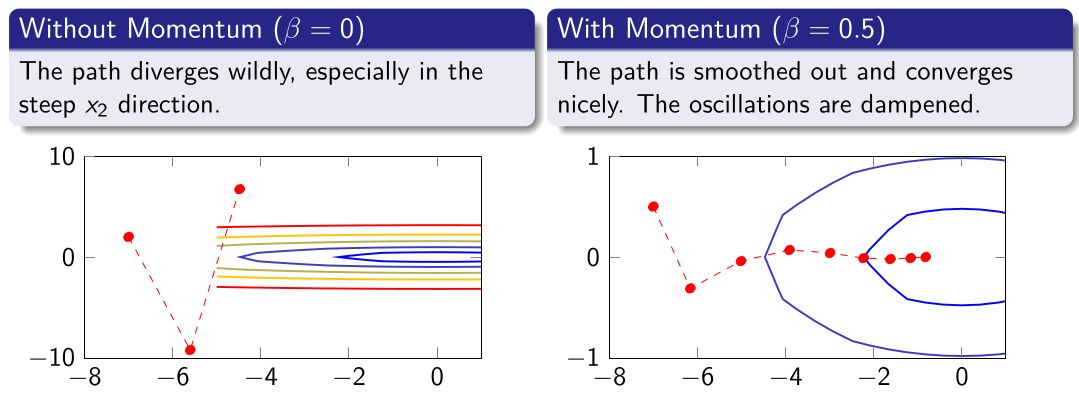

# Adagrad

## A New Problem: Sparse Features

Imagine training a language model. The learning rate $\eta$ decreases over time for all parameters.

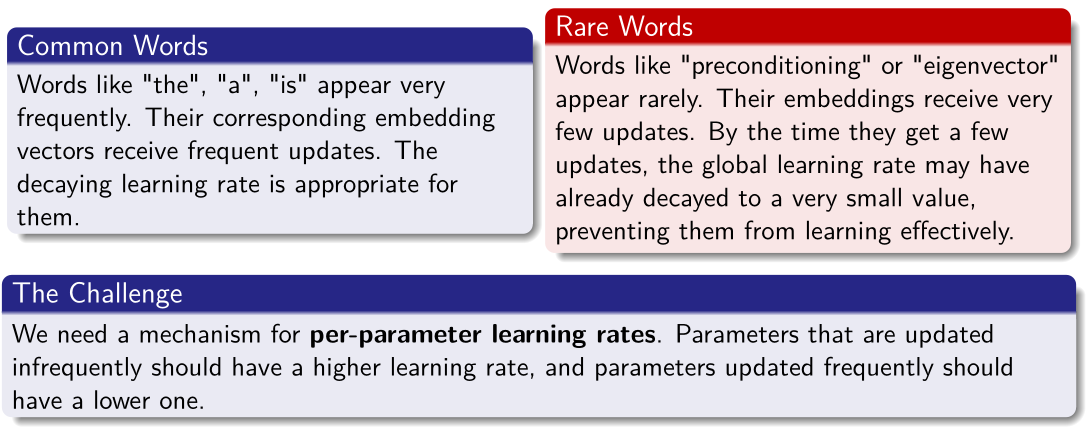

